## 1. Import the library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# ML imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score,
                            accuracy_score, precision_score, recall_score)

from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.base import BaseEstimator, TransformerMixin


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
warnings.filterwarnings('ignore')

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
# Configuration
RANDOM_STATE = 2025
np.random.seed(RANDOM_STATE)

C:\Users\Admin\.conda\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1.1 Load Data
base_dir = Path.cwd().parent
data_path_train = base_dir / "data" / "processed" / "olist_preprocessed.csv"
train_data = pd.read_csv(data_path_train)
print(f"Training set: {train_data.shape[0]: ,} rows x {train_data.shape[1]} columns")
train_data.head()

Training set:  94,867 rows x 33 columns


,is_satisfied,delivery_delay_days,estimated_delivery_days,actual_delivery_days,carrier_to_customer_days,review_answer_delay_days,total_order_value,total_items,payment_installments,customer_lat,...,seller_state_enc,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,category_enc,is_early_delivery,distance_km_log,delivery_speed_ratio,seller_reliability_score,delay_x_seller_risk
0,0,-15,22,7.0,5.0,1,34.59,1,1.0,-19.7402,...,21,0,0,0,0.198166,1,5.092836,0.318182,4.174000,-0.0000
1,0,-8,21,13.0,6.0,3,126.54,2,1.0,-23.5324,...,21,0,0,0,0.202359,1,5.986006,0.619048,3.691654,-0.6056
2,0,-6,14,8.0,7.0,0,127.55,1,1.0,-21.4106,...,14,0,0,0,0.181772,1,6.763933,0.571429,4.274262,-0.0594
3,0,-13,20,7.0,4.0,0,112.71,1,1.0,-23.1948,...,21,0,0,0,0.183531,1,5.522066,0.350000,3.816720,-1.0985
4,0,-7,9,2.0,1.0,0,35.84,1,1.0,-23.7409,...,21,0,0,0,0.155620,1,4.257464,0.222222,3.748683,-0.5558


## 2. TRAIN-TEST SPLIT WITH STRATIFICATION

In [3]:
df = train_data.copy()
X = df.drop('is_satisfied', axis=1)
y = df['is_satisfied']

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, stratify= y, random_state = RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = RANDOM_STATE )

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (66406, 32)
Validation set size: (14230, 32)
Test set size: (14231, 32)


In [5]:
print(f"\nTrain set olist satisfaction:")
print(y_train.value_counts(normalize=True).rename({0: 'Satisfied', 1: 'Unsatisfied'}))


Train set olist satisfaction:
is_satisfied
Satisfied      0.789944
Unsatisfied    0.210056
Name: proportion, dtype: float64


In [6]:
print(f"\nValidation set olist satisfaction")
print(y_val.value_counts(normalize = True).rename({0: 'Satisfied', 1: 'Unsatisfied'}))


Validation set olist satisfaction
is_satisfied
Satisfied      0.789951
Unsatisfied    0.210049
Name: proportion, dtype: float64


In [7]:
print(f"\nTest set olist satisfaction:")
print(y_test.value_counts(normalize=True).rename({0: 'Satisfied', 1: 'Unsatisfied'}))


Test set olist satisfaction:
is_satisfied
Satisfied      0.789966
Unsatisfied    0.210034
Name: proportion, dtype: float64


## 3. Feature Selection

In [8]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [9]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_pipeline['classifier'].feature_importances_
}).sort_values('importance', ascending=False)
feature_importance

,feature,importance
29,delivery_speed_ratio,0.102492
30,seller_reliability_score,0.099043
0,delivery_delay_days,0.084938
31,delay_x_seller_risk,0.084898
20,actual_delivery_days_log,0.059299
6,total_items,0.055501
3,carrier_to_customer_days,0.048023
2,actual_delivery_days,0.043212
27,is_early_delivery,0.039194
17,total_freight_value_log,0.031906


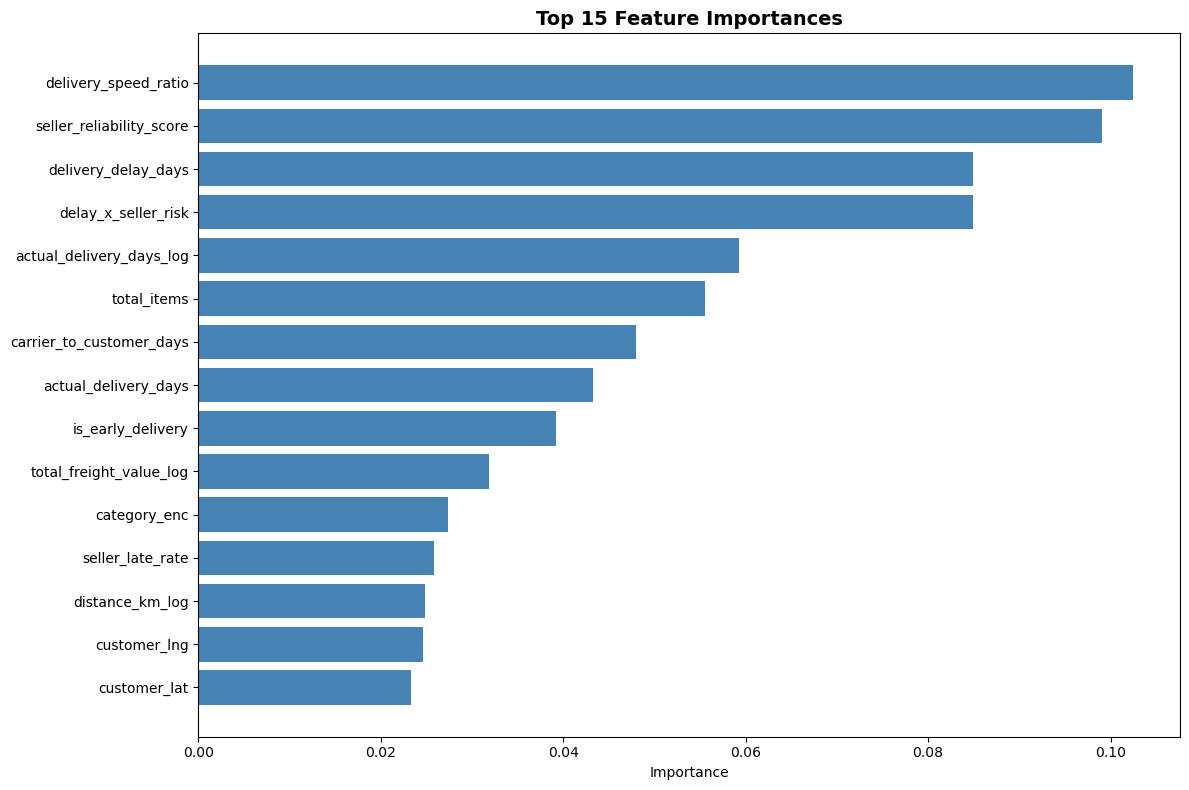


 TOP 10 IMPORTANT FEATURES
                     feature  importance
29      delivery_speed_ratio    0.102492
30  seller_reliability_score    0.099043
0        delivery_delay_days    0.084938
31       delay_x_seller_risk    0.084898
20  actual_delivery_days_log    0.059299
6                total_items    0.055501
3   carrier_to_customer_days    0.048023
2       actual_delivery_days    0.043212
27         is_early_delivery    0.039194
17   total_freight_value_log    0.031906


In [10]:
# Plot
plt.figure(figsize=(12, 8))
plt.barh(range(len(feature_importance.head(15))), feature_importance.head(15)['importance'], color='steelblue')
plt.yticks(range(len(feature_importance.head(15))), feature_importance.head(15)['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n TOP 10 IMPORTANT FEATURES")
print(feature_importance.head(10))

In [ ]:
selected_features = feature_importance[feature_importance['importance'] > 0.004 ]['feature'].tolist()
print(f'Selected: {len(selected_features)} / {X_train.shape[1]} features')

Selected: 29 / 32 features


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for label, col in [
    (f"Columns: {X_train.shape[1]}",X_train),
    (f"Columns: {len(selected_features)}", X_train[selected_features])
]:
    rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    score = cross_val_score(rf_base, col, y_train, cv = cv, scoring= 'roc_auc').mean()
    print(f"{label}: AUC {score: .4f}")

Columns: 32: AUC  0.7184
Columns: 29: AUC  0.7190


In [13]:
# Áp dụng feature selection
X_train_sel = X_train[selected_features].copy()
X_val_sel   = X_val[selected_features].copy()
X_test_sel  = X_test[selected_features].copy()

# Class imbalance ratio cho XGBoost
satisfied_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {satisfied_ratio:.2f}')
print(f'Train shape: {X_train_sel.shape}')

scale_pos_weight = 3.76
Train shape: (66406, 29)


## 4. Modeling

In [14]:
def evaluate_model(model, X_train, y_train, X_test, y_test, X_val, y_val, model_name):
    # Fit Model
    if model_name == "XGBoost":
        model.fit(X_train, y_train, eval_set = [(X_val, y_val)], verbose = False)
    else:
        model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Metric
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division= 0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    
    return results, y_pred, y_pred_proba

In [15]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize = (8, 6))
    sns.heatmap(cm, cmap = 'Blues', annot = True, fmt = 'd', cbar= False, xticklabels = ['Satisfied', 'Unsatisfied'], yticklabels = ['Satisfied', 'Unsatisfied'])
    plt.title(f'Confusion matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Calculate additional metrics from confusion matrix
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix Details:")
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")

In [16]:
def plot_roc_curve(y_test, y_pred_proba, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    plt.figure(figsize = (8, 6))
    plt.plot(fpr, tpr, color = 'darkorange', lw = 2, label = f'ROC curve (AUC = {roc_auc: .3f})')
    plt.plot([0,1],[0,1], color = 'navy', lw = 2, linestyle = '--', label = 'Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC-Curve {model_name}')
    plt.legend(loc = 'lower right')
    plt.grid(alpha = 0.3)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_prec_curve(y_test, y_pred_proba, model_name):
    prec, rec, threshold = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    baseline = y_test.mean()

    plt.figure(figsize= (8, 6))
    plt.plot(rec, prec, color ='green', lw = 2, label = f'PR-AUC = {pr_auc: .3f}')
    plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline = {baseline:.3f}')
    plt.xlabel('Recall'); 
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='upper right'); 
    plt.grid(alpha=0.3)
    plt.show()

### 4.1 Logistic Regression

Logistic Regression Results:
Model: Logistic Regression
Accuracy: 0.73
Precision: 0.40
Recall: 0.57
F1-Score: 0.47
ROC-AUC: 0.74
PR-AUC: 0.51


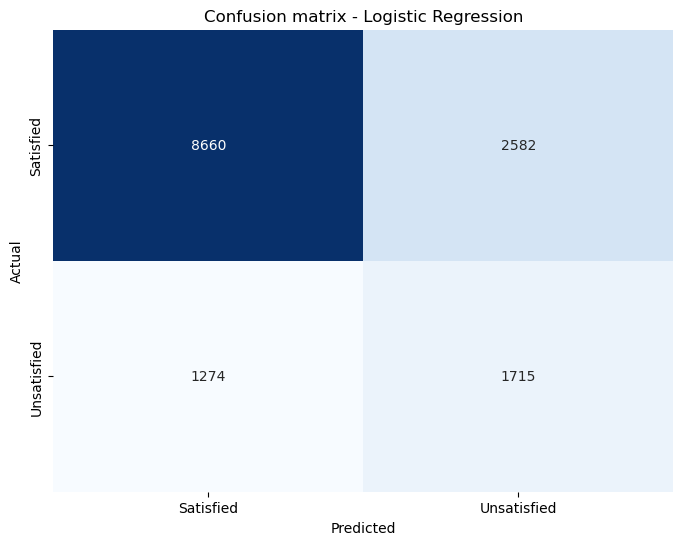


Confusion Matrix Details:
True Negatives (TN): 8660
False Positives (FP): 2582
False Negatives (FN): 1274
True Positives (TP): 1715

              precision    recall  f1-score   support

   Satisfied       0.87      0.77      0.82     11242
 Unsatisfied       0.40      0.57      0.47      2989

    accuracy                           0.73     14231
   macro avg       0.64      0.67      0.64     14231
weighted avg       0.77      0.73      0.74     14231



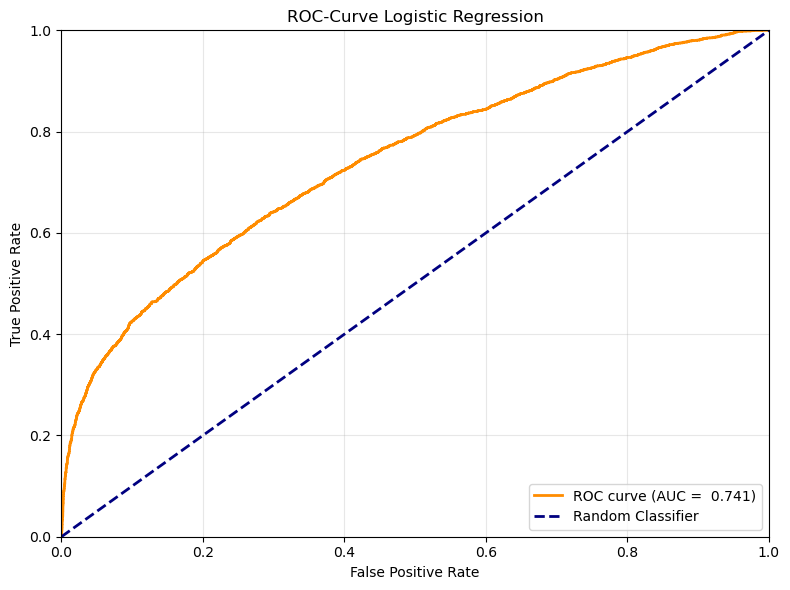

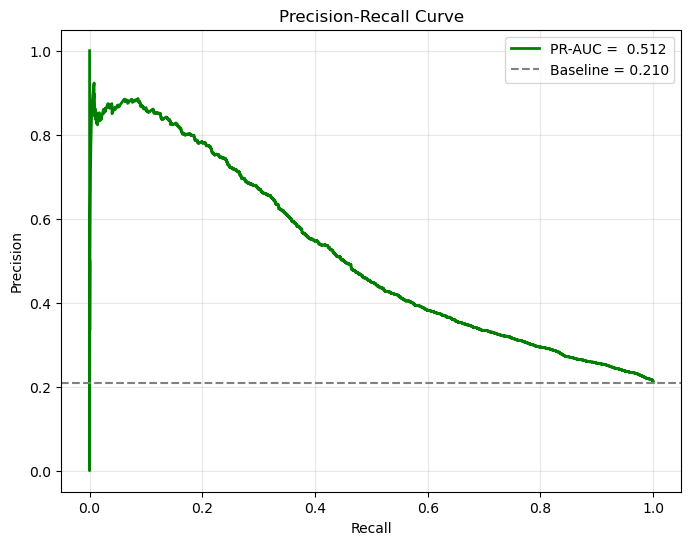

In [18]:
all_results = []

# Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1, random_state = RANDOM_STATE))
])
lr_result, y_pred, y_pred_proba_lg = evaluate_model(lr_pipeline, X_train_sel, y_train, X_test_sel, y_test, X_val_sel, y_val, 'Logistic Regression')
all_results.append(lr_result)

print("Logistic Regression Results:")
for k, v in lr_result.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")

# Confusion
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression')
print("\n" + classification_report(y_test, y_pred, target_names=['Satisfied', 'Unsatisfied']))
# ROC-AUC
if y_pred_proba_lg is not None:
    plot_roc_curve(y_test, y_pred_proba_lg, 'Logistic Regression')

# Pr-AUC
plot_prec_curve(y_test, y_pred_proba_lg, 'Logistic Regression')

### 4.2 Random Forest

Random Forest Results:
Model: Random Forest
Accuracy: 0.80
Precision: 0.53
Recall: 0.43
F1-Score: 0.48
ROC-AUC: 0.75
PR-AUC: 0.54


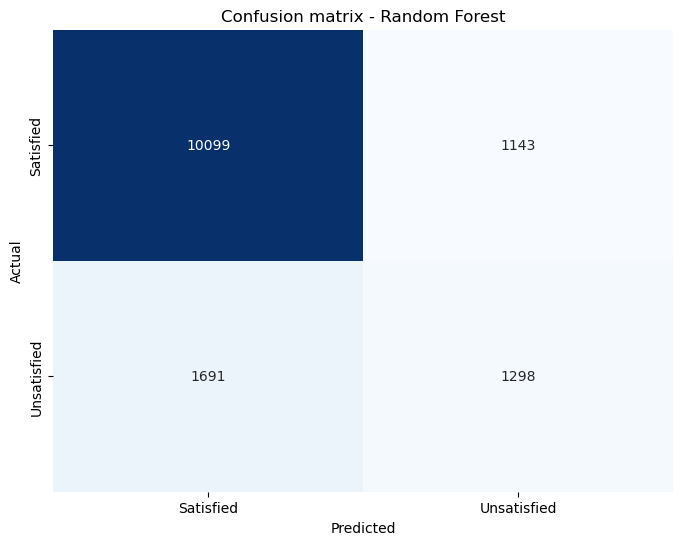


Confusion Matrix Details:
True Negatives (TN): 10099
False Positives (FP): 1143
False Negatives (FN): 1691
True Positives (TP): 1298

              precision    recall  f1-score   support

   Satisfied       0.86      0.90      0.88     11242
 Unsatisfied       0.53      0.43      0.48      2989

    accuracy                           0.80     14231
   macro avg       0.69      0.67      0.68     14231
weighted avg       0.79      0.80      0.79     14231



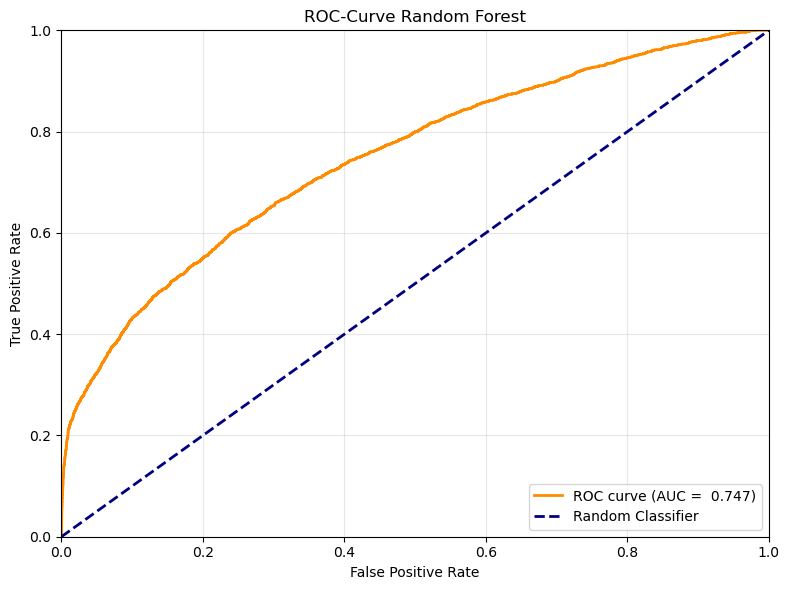

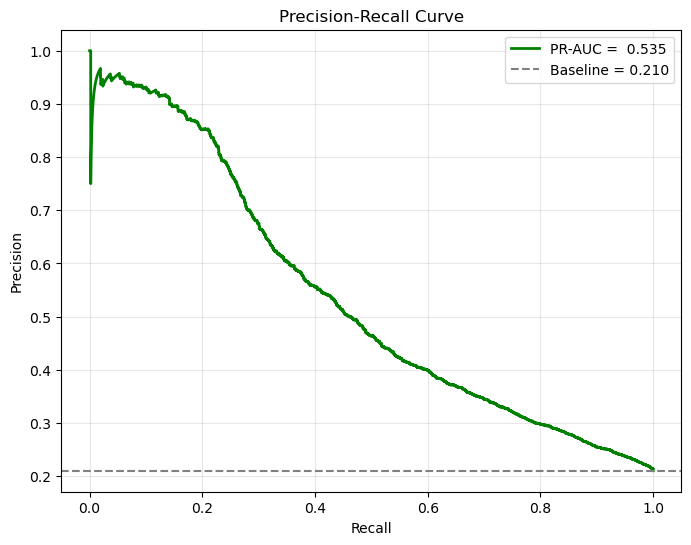

In [19]:
rfs_model = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_leaf=5,
    class_weight='balanced', random_state= RANDOM_STATE, n_jobs=-1
)
rfs_result, y_pred, y_pred_proba_rf = evaluate_model(rfs_model, X_train_sel, y_train, X_test_sel, y_test, X_val_sel, y_val, 'Random Forest')
all_results.append(rfs_result)

print("Random Forest Results:")
for k, v in rfs_result.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")

# Confusion
plot_confusion_matrix(y_test, y_pred, 'Random Forest')
print("\n" + classification_report(y_test, y_pred, target_names=['Satisfied', 'Unsatisfied']))
# ROC-AUC
if y_pred_proba_rf is not None:
    plot_roc_curve(y_test, y_pred_proba_rf, 'Random Forest')

# PR-AUC
plot_prec_curve(y_test, y_pred_proba_rf, 'Random Forest')

### 4.3 XGBoost

XGBoost Results:
Model: XGBoost
Accuracy: 0.74
Precision: 0.42
Recall: 0.58
F1-Score: 0.49
ROC-AUC: 0.75
PR-AUC: 0.54


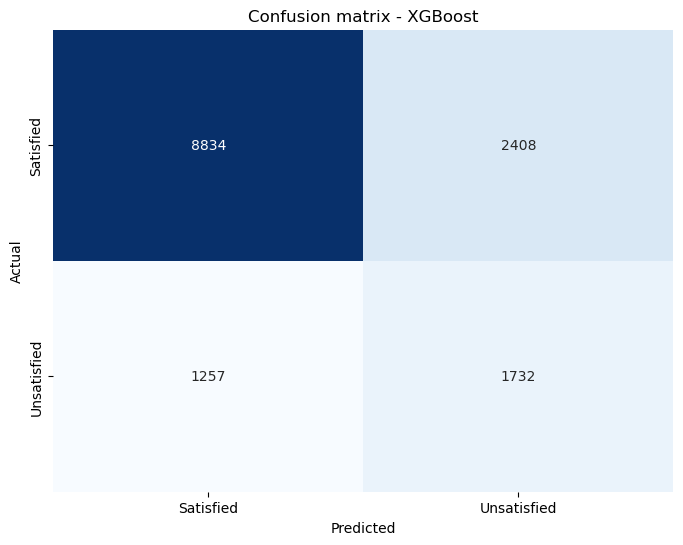


Confusion Matrix Details:
True Negatives (TN): 8834
False Positives (FP): 2408
False Negatives (FN): 1257
True Positives (TP): 1732

              precision    recall  f1-score   support

   Satisfied       0.88      0.79      0.83     11242
 Unsatisfied       0.42      0.58      0.49      2989

    accuracy                           0.74     14231
   macro avg       0.65      0.68      0.66     14231
weighted avg       0.78      0.74      0.76     14231



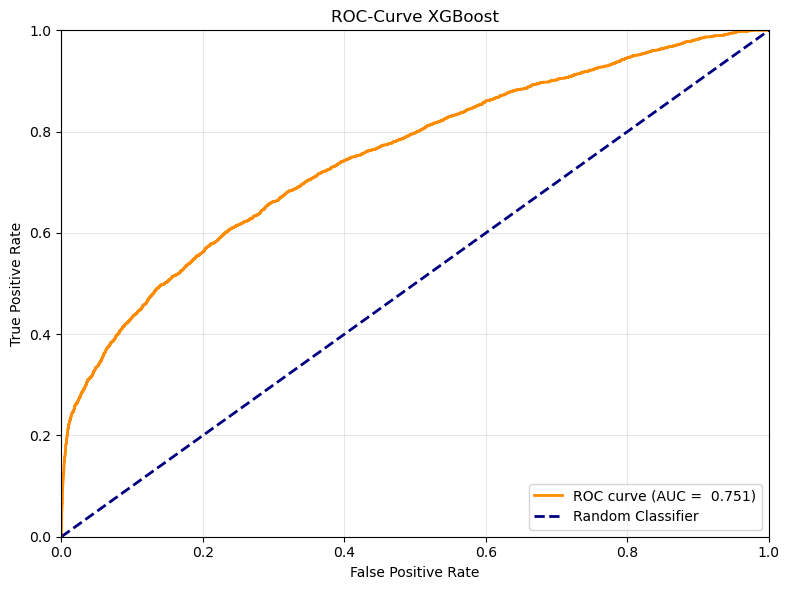

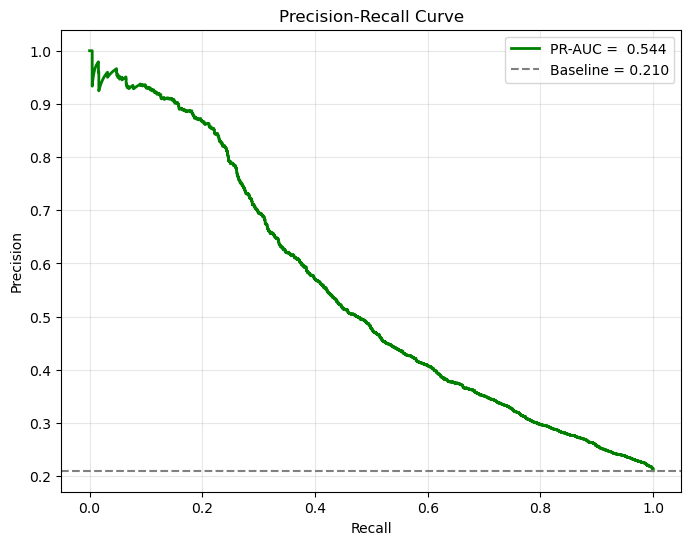

In [20]:
xgb_model = XGBClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.04,
    subsample=0.8, colsample_bytree=0.8, gamma=0.1,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight= satisfied_ratio, early_stopping_rounds=20,
    eval_metric='auc', random_state = RANDOM_STATE, n_jobs=-1
)
xgb_result, y_pred, y_pred_proba_gb = evaluate_model(xgb_model, X_train_sel, y_train, X_test_sel, y_test, X_val_sel, y_val, 'XGBoost')
all_results.append(xgb_result)

print("XGBoost Results:")
for k, v in xgb_result.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")
# Confusion
plot_confusion_matrix(y_test, y_pred, 'XGBoost')
print("\n" + classification_report(y_test, y_pred, target_names=['Satisfied', 'Unsatisfied']))
# ROC-AUC
if y_pred_proba_gb is not None:
    plot_roc_curve(y_test, y_pred_proba_gb, 'XGBoost')

# PR-AUC
plot_prec_curve(y_test, y_pred_proba_gb, 'XGBoost')

## 4.4 LightGBM

LightGBM Results:
Model: LightGBM
Accuracy: 0.74
Precision: 0.42
Recall: 0.58
F1-Score: 0.49
ROC-AUC: 0.75
PR-AUC: 0.55


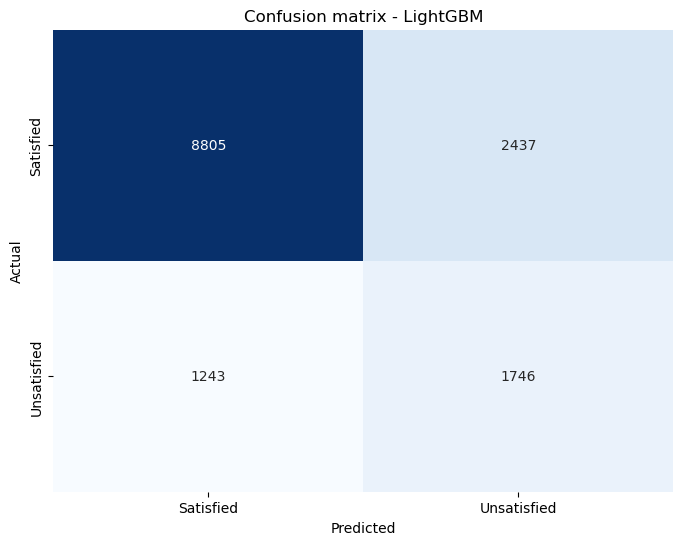


Confusion Matrix Details:
True Negatives (TN): 8805
False Positives (FP): 2437
False Negatives (FN): 1243
True Positives (TP): 1746

              precision    recall  f1-score   support

   Satisfied       0.88      0.78      0.83     11242
 Unsatisfied       0.42      0.58      0.49      2989

    accuracy                           0.74     14231
   macro avg       0.65      0.68      0.66     14231
weighted avg       0.78      0.74      0.76     14231



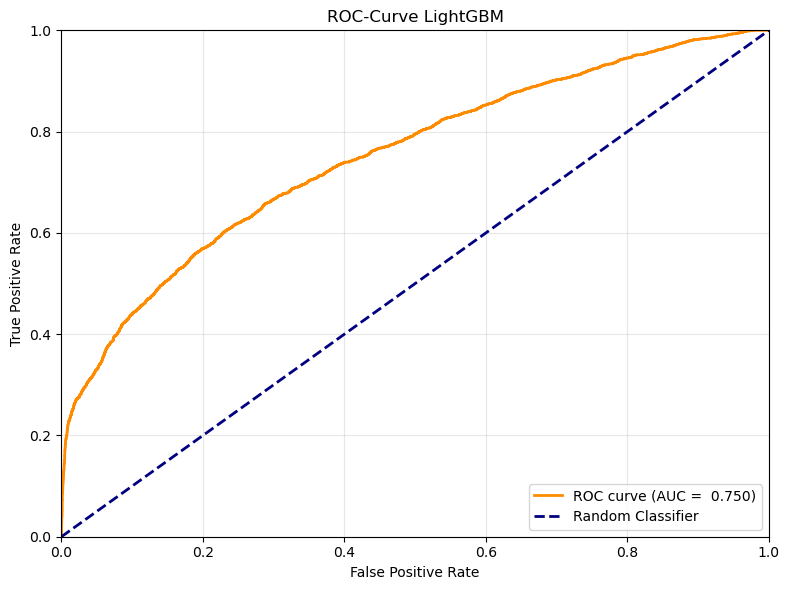

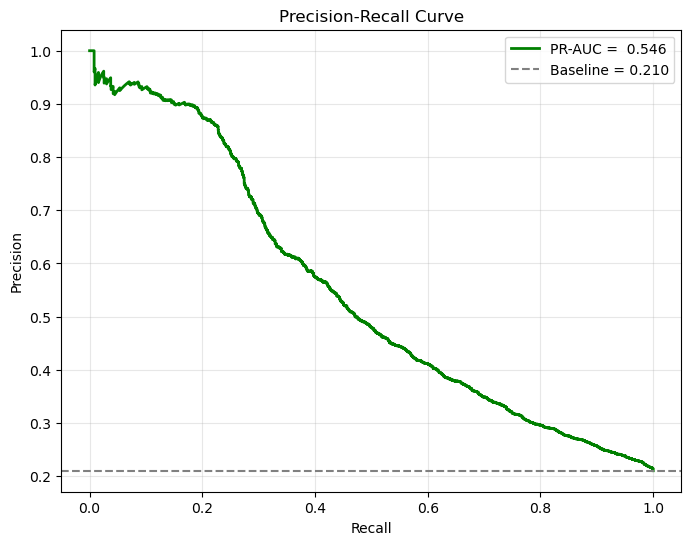

In [21]:
lgb_model = LGBMClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_result, y_pred_lgb, y_proba_lgb = evaluate_model(lgb_model, X_train_sel, y_train, X_test_sel, y_test, X_val_sel, y_val, 'LightGBM')
all_results.append(lgb_result)

print("LightGBM Results:")
for k, v in lgb_result.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")
# Confusion
plot_confusion_matrix(y_test, y_pred_lgb, 'LightGBM')
print("\n" + classification_report(y_test, y_pred_lgb, target_names=['Satisfied', 'Unsatisfied']))
# ROC-AUC
if y_proba_lgb is not None:
    plot_roc_curve(y_test, y_proba_lgb, 'LightGBM')

# PR-AUC
plot_prec_curve(y_test, y_proba_lgb, 'LightGBM')

In [22]:
results_df = pd.DataFrame(all_results)
print('\n=== Tổng hợp kết quả các models ===')
results_df 


=== Tổng hợp kết quả các models ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.729042,0.399116,0.573770,0.470766,0.740787,0.512020
1,Random Forest,0.800857,0.531749,0.434259,0.478085,0.746687,0.535408
2,XGBoost,0.742464,0.418357,0.579458,0.485903,0.750541,0.544379
3,LightGBM,0.741410,0.417404,0.584142,0.486893,0.750092,0.545749


In [23]:
cv_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 3, 9),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 2.0, log=True),
    }
    model = XGBClassifier(**params, scale_pos_weight=satisfied_ratio, eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1)
    
    # CV chỉ trên train — val/test không được chạm
    scores = cross_val_score(model, X_train_sel, y_train, cv=cv_opt, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f'\nBest ROC-AUC (CV train): {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'{k}: {v}')

  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 5. Best value: 0.744238: 100%|██████████| 40/40 [07:31<00:00, 11.28s/it]


Best ROC-AUC (CV train): 0.7442
Best params:
n_estimators: 524
max_depth: 4
learning_rate: 0.017540324152237753
subsample: 0.6420298405033457
colsample_bytree: 0.7615738593576407
min_child_weight: 7
gamma: 0.899611583656986
reg_alpha: 0.00026029376676781486
reg_lambda: 0.0021919124449409897


## 5. Final Model

In [24]:
# Fit final model with best params
# early_stopping_rounds = 20
best_xgb = XGBClassifier(
    **study.best_params,
    scale_pos_weight=satisfied_ratio,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=RANDOM_STATE, n_jobs=-1
)

# Step 1: Fit with train + val
best_xgb.fit(X_train_sel, y_train, eval_set=[(X_val_sel, y_val)],verbose=False)
print(f'Best iteration: {best_xgb.best_iteration}')

# Step 2: Evaluate with val (check before touching test)
y_pred_val  = best_xgb.predict(X_val_sel)
y_proba_val = best_xgb.predict_proba(X_val_sel)[:, 1]
print('\n--- Validation Set ---')
print(classification_report(y_val, y_pred_val, target_names=['Satisfied', 'Unsatisfied']))
print(f'ROC-AUC: {roc_auc_score(y_val, y_proba_val):.4f}')
print(f'PR-AUC : {average_precision_score(y_val, y_proba_val):.4f}')

Best iteration: 465

--- Validation Set ---
              precision    recall  f1-score   support

   Satisfied       0.87      0.79      0.83     11241
 Unsatisfied       0.42      0.56      0.48      2989

    accuracy                           0.74     14230
   macro avg       0.65      0.68      0.66     14230
weighted avg       0.78      0.74      0.76     14230

ROC-AUC: 0.7486
PR-AUC : 0.5469



--- FINAL TEST RESULTS ---
              precision    recall  f1-score   support

   Satisfied       0.88      0.78      0.83     11242
 Unsatisfied       0.42      0.59      0.49      2989

    accuracy                           0.74     14231
   macro avg       0.65      0.68      0.66     14231
weighted avg       0.78      0.74      0.75     14231

ROC-AUC: 0.7515
PR-AUC : 0.5449


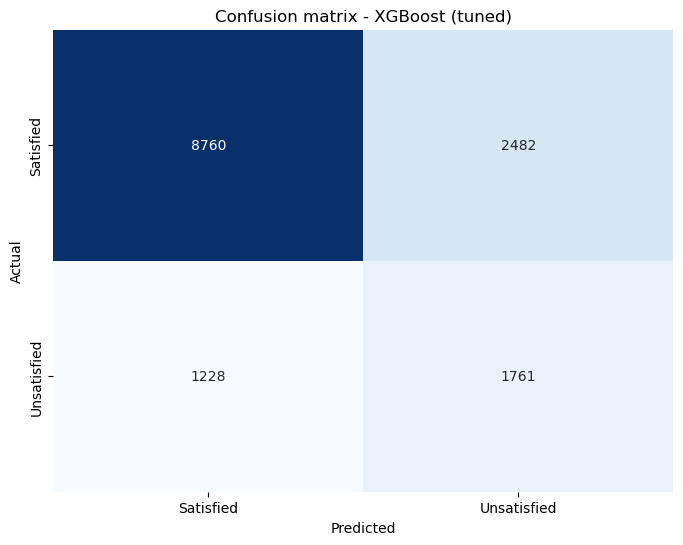


Confusion Matrix Details:
True Negatives (TN): 8760
False Positives (FP): 2482
False Negatives (FN): 1228
True Positives (TP): 1761


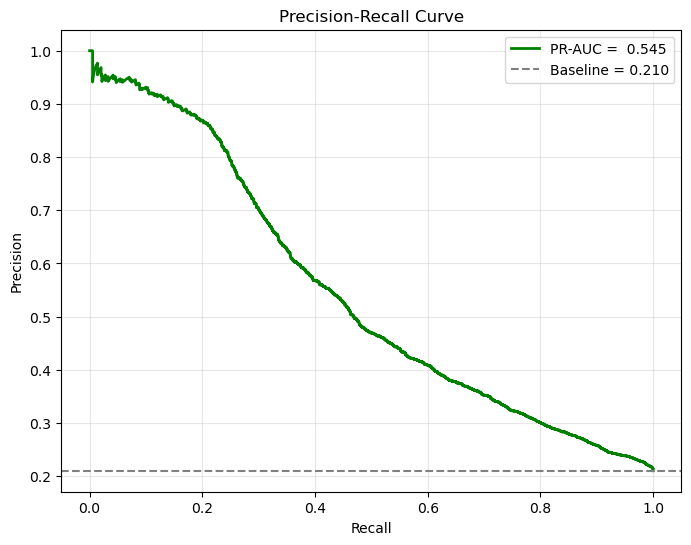

In [25]:
# Step 3: Final evaluation on test — ONLY RUN ONCE
y_pred_final  = best_xgb.predict(X_test_sel)
y_proba_final = best_xgb.predict_proba(X_test_sel)[:, 1]

print('\n--- FINAL TEST RESULTS ---')
print(classification_report(y_test, y_pred_final, target_names=['Satisfied', 'Unsatisfied']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}')
print(f'PR-AUC : {average_precision_score(y_test, y_proba_final):.4f}')

plot_confusion_matrix(y_test, y_pred_final, 'XGBoost (tuned)')
plot_prec_curve(y_test, y_proba_final, 'XGBoost (tuned)')

## 5.1 Threshold Optimization

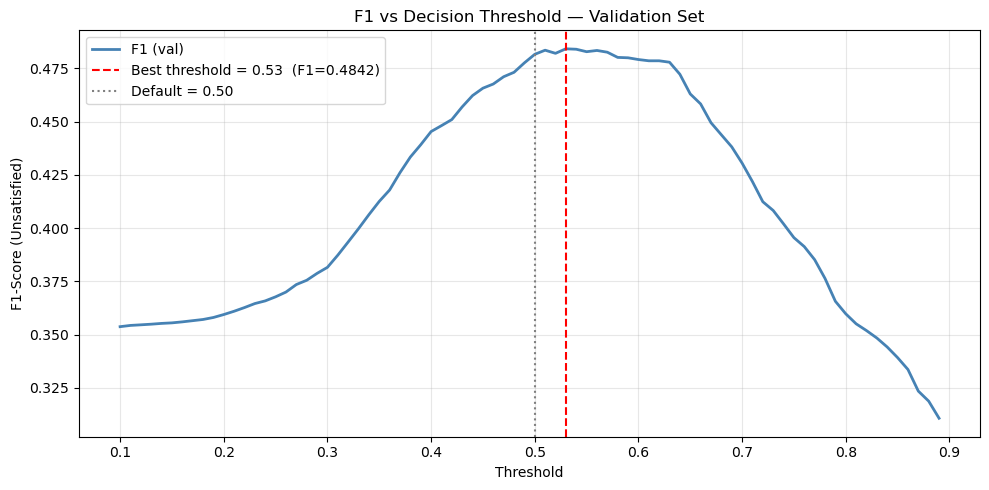

Default threshold  0.50  → Val F1: 0.4816
Optimal threshold 0.53  → Val F1: 0.4842


In [26]:
thresholds = np.arange(0.10, 0.90, 0.01)
f1_vals = []
for t in thresholds:
    y_pred_thresh = (y_proba_val >= t).astype(int)
    f1 = f1_score(y_val, y_pred_thresh)
    f1_vals.append(f1)

f1_vals = np.array(f1_vals)
best_thresh = thresholds[int(np.argmax(f1_vals))]
best_f1_val = max(f1_vals)

# ── Plot F1 vs Threshold ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_vals, color='steelblue', lw=2, label='F1 (val)')
plt.axvline(x=best_thresh, color='red', linestyle='--', label=f'Best threshold = {best_thresh:.2f}  (F1={best_f1_val:.4f})')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default = 0.50')
plt.xlabel('Threshold')
plt.ylabel('F1-Score (Unsatisfied)')
plt.title('F1 vs Decision Threshold — Validation Set')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Default threshold  0.50  → Val F1: {f1_score(y_val, (y_proba_val >= 0.50).astype(int)):.4f}')
print(f'Optimal threshold {best_thresh:.2f}  → Val F1: {best_f1_val:.4f}')

=== FINAL TEST RESULTS — threshold = 0.53 ===
              precision    recall  f1-score   support

   Satisfied       0.87      0.82      0.85     11242
 Unsatisfied       0.45      0.54      0.49      2989

    accuracy                           0.76     14231
   macro avg       0.66      0.68      0.67     14231
weighted avg       0.78      0.76      0.77     14231

ROC-AUC: 0.7515
PR-AUC: 0.5449



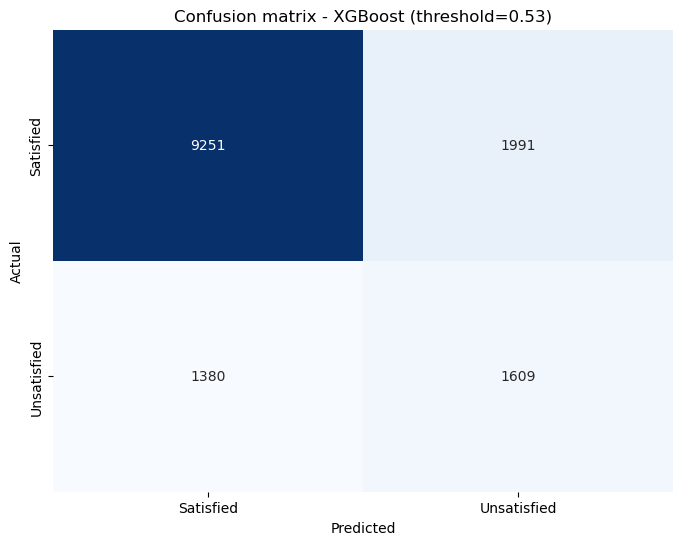


Confusion Matrix Details:
True Negatives (TN): 9251
False Positives (FP): 1991
False Negatives (FN): 1380
True Positives (TP): 1609


In [27]:
# ── Apply optimal threshold to TEST set ────────────────────────────────────
y_pred_thresh = (y_proba_final >= best_thresh).astype(int)

print(f'=== FINAL TEST RESULTS — threshold = {best_thresh:.2f} ===')
print(classification_report(y_test, y_pred_thresh, target_names=['Satisfied', 'Unsatisfied']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_proba_final):.4f}')
print()

plot_confusion_matrix(y_test, y_pred_thresh, f'XGBoost (threshold={best_thresh:.2f})')


## 6. Cross Validation 

In [28]:
cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_model = XGBClassifier(**study.best_params, scale_pos_weight=satisfied_ratio, eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1)

X_cv = pd.concat([X_train_sel, X_val_sel])
y_cv = pd.concat([y_train, y_val])
cv_results = cross_validate(
    cv_model, X_cv, y_cv,
    cv=cv_final,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=True,
    n_jobs=-1
)

print('=== 5-Fold CV Results ===')
print(f'{"Metric":<20} {"Train":>10} {"Val":>10} {"Val Std":>10}')
print('-' * 55)
for m in ['roc_auc', 'f1', 'precision', 'recall']:
    tr_mean = cv_results[f'train_{m}'].mean()
    vl_mean = cv_results[f'test_{m}'].mean()
    vl_std  = cv_results[f'test_{m}'].std()
    print(f'{m:<20} {tr_mean:>10.4f} {vl_mean:>10.4f} {vl_std:>10.4f}')

=== 5-Fold CV Results ===
Metric                    Train        Val    Val Std
-------------------------------------------------------
roc_auc                  0.7679     0.7456     0.0032
f1                       0.4972     0.4789     0.0043
precision                0.4305     0.4151     0.0023
recall                   0.5882     0.5660     0.0094


## 7. Shap

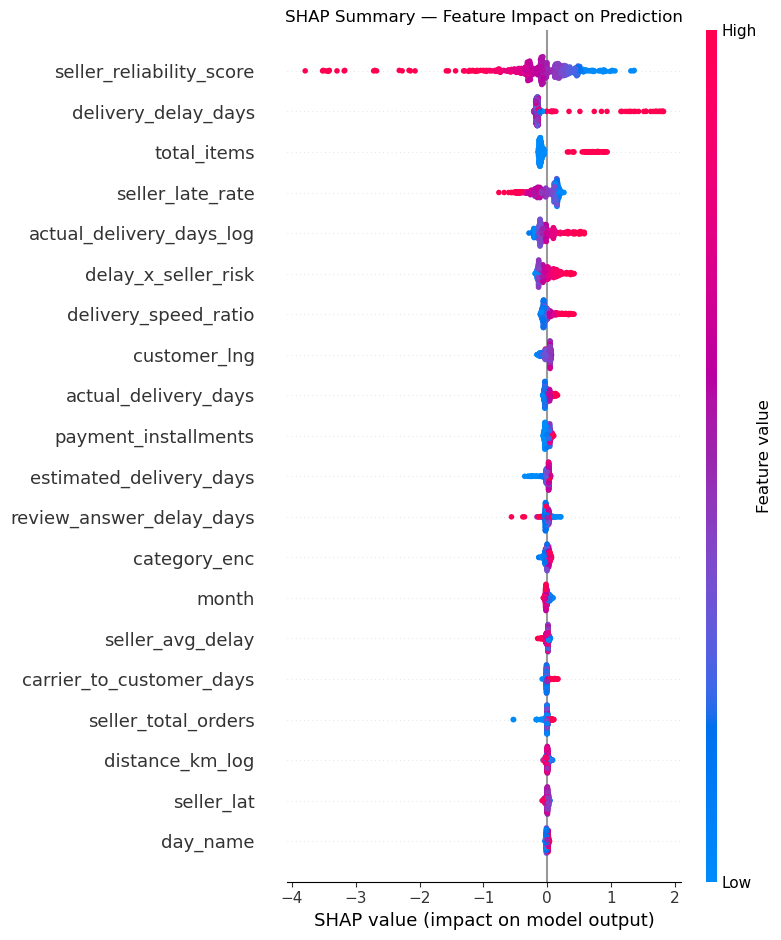

In [29]:
shap_sample = X_test_sel.sample(min(500, len(X_test_sel)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(shap_sample)

# Summary plot: feature importance + direction
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, feature_names=selected_features, plot_type='dot', show=False)
plt.title('SHAP Summary — Feature Impact on Prediction')
plt.tight_layout()
plt.show()

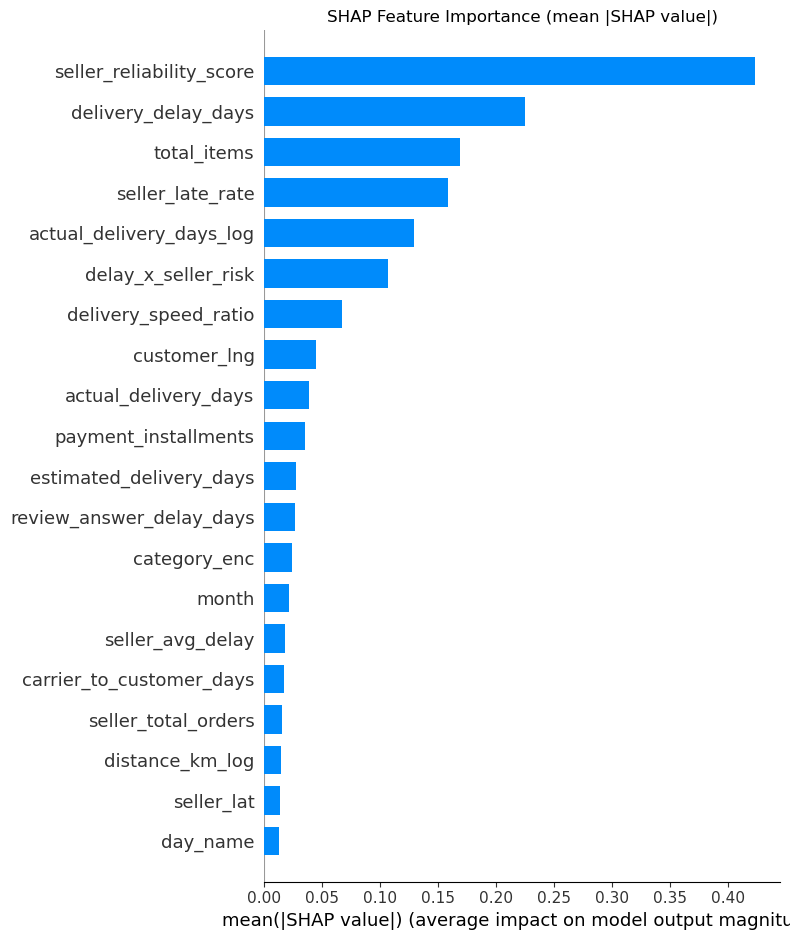

In [30]:
# Bar plot — mean |SHAP|
shap.summary_plot(shap_values, shap_sample, feature_names=selected_features,plot_type='bar', show=False)
plt.title('SHAP Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.show()

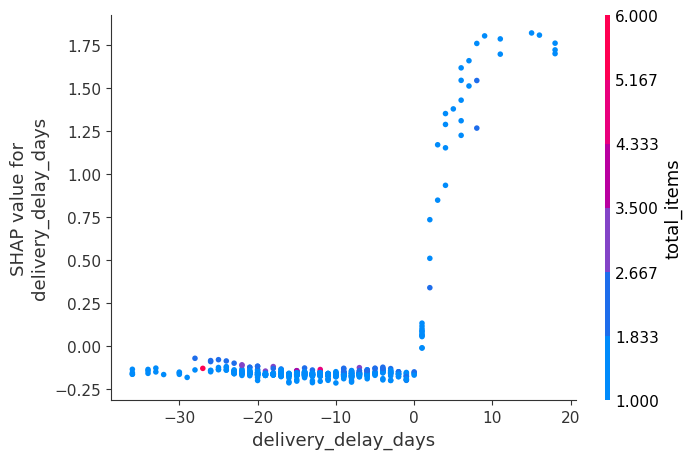

In [31]:
# Dependence plot: xem delivery_delay_days ảnh hưởng thế nào
if 'delivery_delay_days' in selected_features:
    shap.dependence_plot('delivery_delay_days', shap_values, shap_sample, feature_names=selected_features, show=True)